# Hard coal+CCS NPV simulation

Run the hard coal+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_hard_coal_ccs_npv,
)


In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_hard_coal_ccs_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,4654.047262,105.294602,10.798653,3.156693,...,94070000.0,2.568161e+07,1.079865e+07,4.286163e+07,3.997452e+06,1.073066e+07,-1.020586e+09,25000000.0,-40.823444,-0.000041
1,1,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,3947.033508,106.082869,10.755928,3.145827,...,94070000.0,2.587387e+07,1.075593e+07,2.872930e+07,7.923084e+06,2.078782e+07,-7.407858e+08,25000000.0,-29.631432,-0.000030
2,2,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,4832.641611,86.680885,13.076320,3.202663,...,94070000.0,2.114168e+07,1.307632e+07,3.834887e+07,4.697525e+06,1.680561e+07,-9.992970e+08,25000000.0,-39.971878,-0.000040
3,3,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,4492.446541,78.219573,11.479871,3.198507,...,94070000.0,1.907794e+07,1.147987e+07,3.512658e+07,6.611313e+06,2.177429e+07,-8.632830e+08,25000000.0,-34.531321,-0.000035
4,4,hard_coal_ccs,1000000.0,4100.0,243.902439,243902.439024,3219.714204,93.999071,12.370869,3.199810,...,94070000.0,2.292660e+07,1.237087e+07,3.647336e+07,3.982669e+06,1.831650e+07,-5.897716e+08,25000000.0,-23.590865,-0.000024


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-795.193352,-31.807734
std,172.827027,6.913081
min,-1381.245105,-55.249804
5%,-1075.535619,-43.021425
50%,-795.204201,-31.808168
95%,-518.179532,-20.727181
max,-324.514472,-12.980579


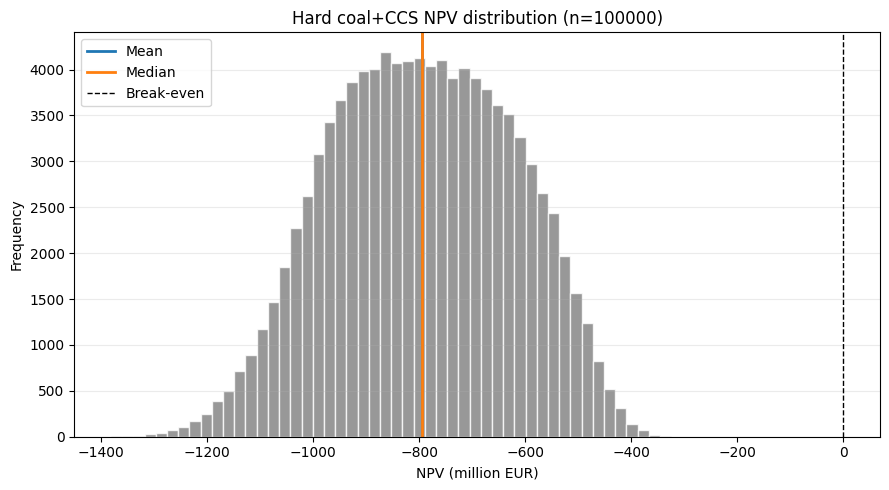

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal+CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

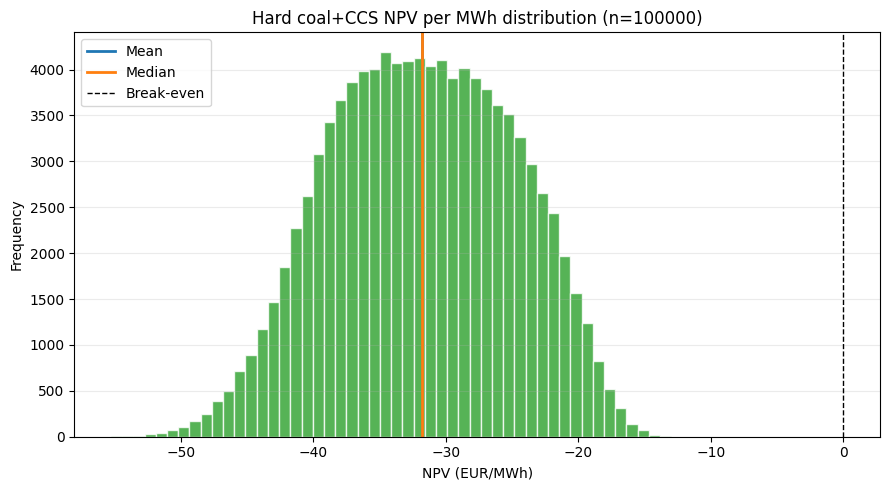

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal+CCS NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        21.085540
annual_variable_opex_eur     11.278856
annual_fuel_cost_eur         38.254617
annual_emissions_cost_eur     4.783186
annual_net_cash_flow_eur     18.667802
Name: Mean annual value, million EUR, dtype: float64